In [1]:
import pandas as pd

In [2]:
v2_snw_copa_df = pd.read_csv('~/PycharmProjects/JupyterProject/data/real_data/No_leakage_Active_COPA_data.csv')

# Parse date column
v2_snw_copa_df['WAC_PRICE_COPA_DATE'] = pd.to_datetime(v2_snw_copa_df['WAC_PRICE_COPA_DATE'])

# Keep only items with at least 2 years of price history before 2024-01-01
cutoff_date = pd.Timestamp('2024-01-01')
min_history_date = cutoff_date - pd.DateOffset(years=2)  # 2022-01-01
items_with_history = (
    v2_snw_copa_df[v2_snw_copa_df['WAC_PRICE_COPA_DATE'] < cutoff_date]
    .groupby('COPA_MTRL_NUM')['WAC_PRICE_COPA_DATE']
    .min()
    .loc[lambda x: x <= min_history_date]
    .index
)
v2_snw_copa_df = v2_snw_copa_df[v2_snw_copa_df['COPA_MTRL_NUM'].isin(items_with_history)]

print(f'Items retained: {v2_snw_copa_df["COPA_MTRL_NUM"].nunique()}')
v2_snw_copa_df.columns
# ── Join THERAPEUTIC_CLASS + MANUFACTURER_NAME from Baseline_model_input ──
bmi = pd.read_csv('~/PycharmProjects/JupyterProject/data/real_data/Baseline_model_input.csv',
                  usecols=['MTRL_NUM','THERAPEUTIC_CLASS','MANUFACTURER_NAME'])
bmi['COPA_MTRL_NUM'] = bmi['MTRL_NUM'].astype(str).str.zfill(18)
bmi = bmi.drop_duplicates('COPA_MTRL_NUM')[['COPA_MTRL_NUM','THERAPEUTIC_CLASS','MANUFACTURER_NAME']]
v2_snw_copa_df['COPA_MTRL_NUM'] = v2_snw_copa_df['COPA_MTRL_NUM'].astype(str).str.zfill(18)
v2_snw_copa_df = v2_snw_copa_df.merge(bmi, on='COPA_MTRL_NUM', how='left')
v2_snw_copa_df['THERAPEUTIC_CLASS'] = pd.to_numeric(v2_snw_copa_df['THERAPEUTIC_CLASS'], errors='coerce').fillna(-1)
v2_snw_copa_df['MANUFACTURER_NAME'] = v2_snw_copa_df['MANUFACTURER_NAME'].fillna('UNKNOWN')
print(f'Therapeutic / Mfr matched: {(v2_snw_copa_df["MANUFACTURER_NAME"]!="UNKNOWN").mean()*100:.1f}%')

# ── Join LOE year via SELL_DSCR substring match on Product Family ──
import openpyxl  # ensure xlsx engine available
loe_xl = pd.read_excel('~/PycharmProjects/JupyterProject/data/real_data/Top_500_Revenue_Materials_BT_05292026_v1.xlsx',
                        sheet_name='LOE_Data')
loe_valid = (
    loe_xl[loe_xl['LOE/Biosim on market'].notna()]
    [['Product Family','LOE/Biosim on market']]
    .rename(columns={'LOE/Biosim on market': 'LOE_YEAR'})
    .drop_duplicates('Product Family')
    .sort_values('Product Family', key=lambda s: s.str.len(), ascending=False)
)
sell_upper = v2_snw_copa_df['SELL_DSCR'].str.upper().fillna('')
loe_series = pd.Series(-1.0, index=v2_snw_copa_df.index)
for _, row in loe_valid.iterrows():
    family = str(row['Product Family']).upper()
    mask = sell_upper.str.contains(family, regex=False) & (loe_series == -1)
    loe_series[mask] = row['LOE_YEAR']
v2_snw_copa_df['LOE_YEAR'] = loe_series
print(f'LOE year matched: {(v2_snw_copa_df["LOE_YEAR"]!=-1).mean()*100:.1f}% of rows')


Items retained: 4309
Therapeutic / Mfr matched: 98.6%
LOE year matched: 5.4% of rows


In [3]:
v2_snw_copa_df.groupby(['COPA_MTRL_NUM','WAC_PRICE_COPA_DATE'])
v2_snw_copa_df.head()

,COPA_FISCAL_YEAR_PERIOD,WAC_PRICE_COPA_DATE,COPA_MTRL_NUM,COPA_NDC_NUM,COPA_WAC_PRICE,PREV_PERIOD_COPA_WAC_PRICE,CUST_PROD_CATEGORY,SNW_NDC_NUM,SNW_MTRL_NUM,SNW_FIRST_EFF_DATE,...,EFFECTIVE_SOURCE,BASELINE_WAC_PRICE,PREV_PERIOD_BASELINE_WAC_PRICE,MATERIAL_CUMULATIVE_REVENUE,TOTAL_CUMULATIVE_REVENUE,BASELINE_MOM_VAR_PCT,CUMULATIVE_REVENUE_PCT_CONTRIBUTION,THERAPEUTIC_CLASS,MANUFACTURER_NAME,LOE_YEAR
0,2022010,2022-01-01,000000000001101567,187301330.0,1052.31,NaN,BX,187301330.0,1101567.0,2022-01-01,...,COPA,1052.31,NaN,0.00,4.588214e+09,NaN,0.000000,120400.0,BAUSCH HEALTH US LLC,-1.0
1,2022011,2022-02-01,000000000001101567,187301330.0,1053.33,1052.31,BX,187301330.0,1101567.0,2022-01-04,...,SNW,1053.33,1053.33,68129.83,6.999570e+09,0.0,0.000010,120400.0,BAUSCH HEALTH US LLC,-1.0
2,2022012,2022-03-01,000000000001101567,187301330.0,1053.33,1053.33,BX,187301330.0,1101567.0,2022-01-04,...,SNW,1053.33,1053.33,117352.15,1.125410e+10,0.0,0.000010,120400.0,BAUSCH HEALTH US LLC,-1.0
3,2023001,2022-04-01,000000000001101567,187301330.0,1053.33,1053.33,BX,187301330.0,1101567.0,2022-01-04,...,SNW,1053.33,1053.33,180525.24,1.365992e+10,0.0,0.000013,120400.0,BAUSCH HEALTH US LLC,-1.0
4,2023002,2022-05-01,000000000001101567,187301330.0,1053.33,1053.33,BX,187301330.0,1101567.0,2022-01-04,...,SNW,1053.33,1053.33,221131.93,1.895925e+10,0.0,0.000012,120400.0,BAUSCH HEALTH US LLC,-1.0


In [4]:
v2_snw_copa_df = v2_snw_copa_df.sort_values(['COPA_MTRL_NUM', 'WAC_PRICE_COPA_DATE'])

In [5]:
# Remove rows with BASELINE_WAC_PRICE < $1 — low-end outliers are unreliable
before = len(v2_snw_copa_df)
v2_snw_copa_df = v2_snw_copa_df[v2_snw_copa_df['BASELINE_WAC_PRICE'] >= 1].copy()
print(f'Dropped {before - len(v2_snw_copa_df):,} rows with BASELINE_WAC_PRICE < $1  '
      f'({before - len(v2_snw_copa_df)}/{before} = {(before - len(v2_snw_copa_df))/before*100:.2f}%)')
print(f'Remaining rows: {len(v2_snw_copa_df):,}')


Dropped 1,075 rows with BASELINE_WAC_PRICE < $1  (1075/214735 = 0.50%)
Remaining rows: 213,660


In [6]:
change_now = (
    v2_snw_copa_df['BASELINE_WAC_PRICE'] != v2_snw_copa_df['PREV_PERIOD_BASELINE_WAC_PRICE']
).astype(int)

v2_snw_copa_df['TGT_CHANGE_UPCOMING_MNTH'] =(
    change_now
    .groupby(v2_snw_copa_df['COPA_MTRL_NUM'])
    .shift(-1)
    .fillna(0)
    .astype(int)
)

In [7]:
v2_snw_copa_df.columns

Index(['COPA_FISCAL_YEAR_PERIOD', 'WAC_PRICE_COPA_DATE', 'COPA_MTRL_NUM',
       'COPA_NDC_NUM', 'COPA_WAC_PRICE', 'PREV_PERIOD_COPA_WAC_PRICE',
       'CUST_PROD_CATEGORY', 'SNW_NDC_NUM', 'SNW_MTRL_NUM',
       'SNW_FIRST_EFF_DATE', 'SNW_LAST_EFF_DATE', 'SNW_PRC_EFF_DT',
       'SNW_WAC_PRICE', 'SELL_DSCR', 'NET_REVENUE',
       'PREV_PERIOD_SNW_WAC_PRICE', 'COPA_SNW_WAC_PRICE_MATCH_IND',
       'COPA_MOM_VAR_PCT', 'SNW_MOM_VAR_PCT', 'IS_FUTURE_PERIOD_FLAG',
       'AVG_COPA_VARIANCE', 'AVG_SNW_VARIANCE', 'SNW_NULL_MONTHS_ROLLING',
       'TOTAL_MONTHS_ROLLING', 'PREFERRED_SOURCE', 'EFFECTIVE_SOURCE',
       'BASELINE_WAC_PRICE', 'PREV_PERIOD_BASELINE_WAC_PRICE',
       'MATERIAL_CUMULATIVE_REVENUE', 'TOTAL_CUMULATIVE_REVENUE',
       'BASELINE_MOM_VAR_PCT', 'CUMULATIVE_REVENUE_PCT_CONTRIBUTION',
       'THERAPEUTIC_CLASS', 'MANUFACTURER_NAME', 'LOE_YEAR',
       'TGT_CHANGE_UPCOMING_MNTH'],
      dtype='str')

In [8]:
training_split = v2_snw_copa_df[v2_snw_copa_df['WAC_PRICE_COPA_DATE'] < '2024-01-01']
validation_split = v2_snw_copa_df[
    (v2_snw_copa_df['WAC_PRICE_COPA_DATE'] >= '2024-01-01') &
    (v2_snw_copa_df['WAC_PRICE_COPA_DATE'] < '2025-01-01')
]
test_split = v2_snw_copa_df[v2_snw_copa_df['WAC_PRICE_COPA_DATE'] >= '2025-01-01']
# Shuffle training set — preserve temporal order in test
training_split = training_split.sample(frac=1, random_state=42).reset_index(drop=True)

In [9]:
print(training_split.columns)


Index(['COPA_FISCAL_YEAR_PERIOD', 'WAC_PRICE_COPA_DATE', 'COPA_MTRL_NUM',
       'COPA_NDC_NUM', 'COPA_WAC_PRICE', 'PREV_PERIOD_COPA_WAC_PRICE',
       'CUST_PROD_CATEGORY', 'SNW_NDC_NUM', 'SNW_MTRL_NUM',
       'SNW_FIRST_EFF_DATE', 'SNW_LAST_EFF_DATE', 'SNW_PRC_EFF_DT',
       'SNW_WAC_PRICE', 'SELL_DSCR', 'NET_REVENUE',
       'PREV_PERIOD_SNW_WAC_PRICE', 'COPA_SNW_WAC_PRICE_MATCH_IND',
       'COPA_MOM_VAR_PCT', 'SNW_MOM_VAR_PCT', 'IS_FUTURE_PERIOD_FLAG',
       'AVG_COPA_VARIANCE', 'AVG_SNW_VARIANCE', 'SNW_NULL_MONTHS_ROLLING',
       'TOTAL_MONTHS_ROLLING', 'PREFERRED_SOURCE', 'EFFECTIVE_SOURCE',
       'BASELINE_WAC_PRICE', 'PREV_PERIOD_BASELINE_WAC_PRICE',
       'MATERIAL_CUMULATIVE_REVENUE', 'TOTAL_CUMULATIVE_REVENUE',
       'BASELINE_MOM_VAR_PCT', 'CUMULATIVE_REVENUE_PCT_CONTRIBUTION',
       'THERAPEUTIC_CLASS', 'MANUFACTURER_NAME', 'LOE_YEAR',
       'TGT_CHANGE_UPCOMING_MNTH'],
      dtype='str')


In [10]:
print(training_split.shape)
print(validation_split.shape)

(99269, 36)
(48285, 36)


In [11]:
cols_to_drop = [
    'TGT_CHANGE_UPCOMING_MNTH',         # target itself
    'BASELINE_WAC_PRICE',
    'WAC_PRICE_COPA_DATE',              # raw date — encoded separately
    'IS_FUTURE_PERIOD_FLAG',            # flags synthetic future rows, not real observations
    'COPA_NDC_NUM',                     # identifier, not a feature
    'COPA_MTRL_NUM',                    # identifier, not a feature
    'SNW_NDC_NUM',                      # identifier
    'SNW_MTRL_NUM',                     # identifier
    'SNW_LAST_EFF_DATE',                 # Leakage knowing that this date signals a price change
    'COPA_WAC_PRICE',
    'SNW_WAC_PRICE',
    'COPA_SNW_WAC_PRICE_MATCH_IND',
    'PREFERRED_SOURCE',
    'EFFECTIVE_SOURCE',
    'SELL_DSCR',
    'PREV_PERIOD_COPA_WAC_PRICE',
    'PREV_PERIOD_SNW_WAC_PRICE'
]
# NOTE: BASELINE_MOM_VAR_PCT and PREV_PERIOD_BASELINE_WAC_PRICE are kept —
# they reflect the *current* period trend, not future data.
y_train = v2_snw_copa_df['TGT_CHANGE_UPCOMING_MNTH']

In [12]:
X_train = v2_snw_copa_df.drop(cols_to_drop, axis=1)

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X_train['CUST_PROD_CATEGORY'] = le.fit_transform(X_train['CUST_PROD_CATEGORY'].astype(str))

# Store mapping for reference / inverse transform
prod_category_classes = list(le.classes_)
print(f"Encoded {len(prod_category_classes)} product categories: {prod_category_classes}")
# Encode MANUFACTURER_NAME
le_mfr = LabelEncoder()
X_train['MANUFACTURER_NAME'] = le_mfr.fit_transform(X_train['MANUFACTURER_NAME'].astype(str))
# THERAPEUTIC_CLASS and LOE_YEAR are numeric — no encoding needed
X_train['THERAPEUTIC_CLASS'] = X_train['THERAPEUTIC_CLASS'].fillna(-1).astype(float)
X_train['LOE_YEAR'] = X_train['LOE_YEAR'].fillna(-1).astype(float)
print('Tree feature matrix shape:', X_train.shape)


Encoded 8 product categories: ['APOLLO', 'BIOSIMS', 'BX', 'DROP SHIP', 'GLP-1', 'MPB Plasma', 'MPB Specialty', 'VAX']
Tree feature matrix shape: (213660, 19)


In [14]:
# Convert date columns to numeric (days since epoch)
date_cols = ['SNW_FIRST_EFF_DATE', 'SNW_LAST_EFF_DATE', 'SNW_PRC_EFF_DT']
for col in date_cols:
    if col in X_train.columns:
        X_train[col] = pd.to_datetime(X_train[col], errors='coerce').map(
            lambda x: x.toordinal() if pd.notna(x) else -1
        )

# Label-encode any remaining object columns
remaining_str_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print(f'Remaining string columns to encode: {remaining_str_cols}')
for col in remaining_str_cols:
    X_train[col] = LabelEncoder().fit_transform(X_train[col].astype(str))

print('All columns now numeric. dtypes:')
print(X_train.dtypes)

Remaining string columns to encode: []
All columns now numeric. dtypes:
COPA_FISCAL_YEAR_PERIOD                  int64
CUST_PROD_CATEGORY                       int64
SNW_FIRST_EFF_DATE                       int64
SNW_PRC_EFF_DT                           int64
NET_REVENUE                            float64
COPA_MOM_VAR_PCT                       float64
SNW_MOM_VAR_PCT                        float64
AVG_COPA_VARIANCE                      float64
AVG_SNW_VARIANCE                       float64
SNW_NULL_MONTHS_ROLLING                  int64
TOTAL_MONTHS_ROLLING                     int64
PREV_PERIOD_BASELINE_WAC_PRICE         float64
MATERIAL_CUMULATIVE_REVENUE            float64
TOTAL_CUMULATIVE_REVENUE               float64
BASELINE_MOM_VAR_PCT                   float64
CUMULATIVE_REVENUE_PCT_CONTRIBUTION    float64
THERAPEUTIC_CLASS                      float64
MANUFACTURER_NAME                        int64
LOE_YEAR                               float64
dtype: object


In [15]:
X_train.columns

Index(['COPA_FISCAL_YEAR_PERIOD', 'CUST_PROD_CATEGORY', 'SNW_FIRST_EFF_DATE',
       'SNW_PRC_EFF_DT', 'NET_REVENUE', 'COPA_MOM_VAR_PCT', 'SNW_MOM_VAR_PCT',
       'AVG_COPA_VARIANCE', 'AVG_SNW_VARIANCE', 'SNW_NULL_MONTHS_ROLLING',
       'TOTAL_MONTHS_ROLLING', 'PREV_PERIOD_BASELINE_WAC_PRICE',
       'MATERIAL_CUMULATIVE_REVENUE', 'TOTAL_CUMULATIVE_REVENUE',
       'BASELINE_MOM_VAR_PCT', 'CUMULATIVE_REVENUE_PCT_CONTRIBUTION',
       'THERAPEUTIC_CLASS', 'MANUFACTURER_NAME', 'LOE_YEAR'],
      dtype='str')

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestClassifier(n_estimators=100, max_features='sqrt',max_depth=8, class_weight='balanced',random_state=42)
rf_history = rf_model.fit(X_train, y_train)

              precision    recall  f1-score   support

   No Change       0.97      0.84      0.90     43556
Price Change       0.34      0.76      0.47      4729

    accuracy                           0.83     48285
   macro avg       0.66      0.80      0.69     48285
weighted avg       0.91      0.83      0.86     48285



/var/folders/02/411qwrs54zv2qs02t9n6pzh40000gp/T/ipykernel_94044/4013756814.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X_test.select_dtypes(include=['object']).columns:


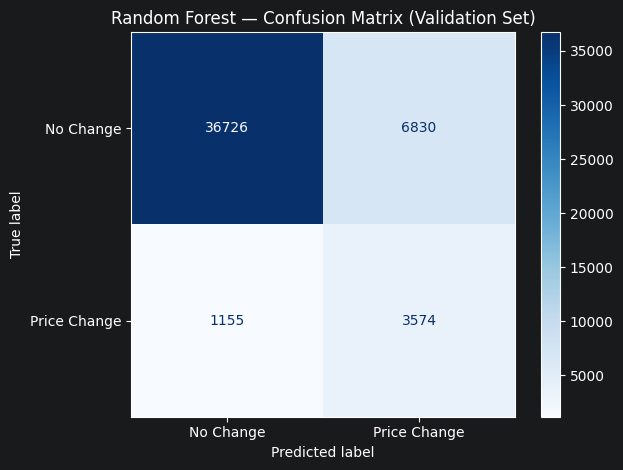

In [17]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Extract y_test before dropping columns
y_test = validation_split['TGT_CHANGE_UPCOMING_MNTH']

# Prepare test features — drop same cols as training, ignore any missing
X_test = validation_split.drop(cols_to_drop, axis=1, errors='ignore').copy()

# Apply same encodings as training
X_test['CUST_PROD_CATEGORY'] = le.transform(
    X_test['CUST_PROD_CATEGORY'].astype(str).map(
        lambda x: x if x in le.classes_ else le.classes_[0]
    )
)
for col in ['SNW_FIRST_EFF_DATE', 'SNW_LAST_EFF_DATE', 'SNW_PRC_EFF_DT']:
    if col in X_test.columns:
        X_test[col] = pd.to_datetime(X_test[col], errors='coerce').map(
            lambda x: x.toordinal() if pd.notna(x) else -1
        )
for col in X_test.select_dtypes(include=['object']).columns:
    X_test[col] = LabelEncoder().fit_transform(X_test[col].astype(str))

# Align columns to match training set exactly
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Predict and evaluate
y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['No Change', 'Price Change']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Change', 'Price Change'])
disp.plot(cmap='Blues')
plt.title('Random Forest — Confusion Matrix (Validation Set)')
plt.tight_layout()
plt.show()

In [18]:
# ── Regression: forecast next month WAC price ──────────────────────────
# Compute target on full df FIRST, then re-slice splits so they inherit it
v2_snw_copa_df["TGT_NEXT_MONTH_WAC"] = (
    v2_snw_copa_df.groupby("COPA_MTRL_NUM")["BASELINE_WAC_PRICE"]
    .shift(-1)
)

# Re-slice so splits have the new column
reg_train_full = v2_snw_copa_df[v2_snw_copa_df["WAC_PRICE_COPA_DATE"] < "2024-01-01"]
reg_test_full  = v2_snw_copa_df[
    (v2_snw_copa_df["WAC_PRICE_COPA_DATE"] >= "2024-01-01") &
    (v2_snw_copa_df["WAC_PRICE_COPA_DATE"] <  "2025-01-01")
]

reg_cols_to_drop = [
    "TGT_NEXT_MONTH_WAC",
    "TGT_CHANGE_UPCOMING_MNTH",
    "BASELINE_WAC_PRICE",
    "WAC_PRICE_COPA_DATE",
    "IS_FUTURE_PERIOD_FLAG",
    "COPA_NDC_NUM",
    "COPA_MTRL_NUM",
    "SNW_NDC_NUM",
    "SNW_MTRL_NUM",
    "SNW_LAST_EFF_DATE",
]

# Drop rows where target is unknown (last month per material has no next month)
reg_train = reg_train_full.dropna(subset=["TGT_NEXT_MONTH_WAC"]).copy()
reg_test  = reg_test_full.dropna(subset=["TGT_NEXT_MONTH_WAC"]).copy()

y_reg_train = reg_train["TGT_NEXT_MONTH_WAC"]
y_reg_test  = reg_test["TGT_NEXT_MONTH_WAC"]

X_reg_train = reg_train.drop(reg_cols_to_drop, axis=1, errors="ignore")
X_reg_test  = reg_test.drop(reg_cols_to_drop, axis=1, errors="ignore")
print(f"reg_train: {X_reg_train.shape}, reg_test: {X_reg_test.shape}")

reg_train: (99165, 27), reg_test: (48207, 27)


In [19]:
# Encode categoricals and dates — same pattern as classifier
le_reg = LabelEncoder()
X_reg_train["CUST_PROD_CATEGORY"] = le_reg.fit_transform(X_reg_train["CUST_PROD_CATEGORY"].astype(str))
X_reg_test["CUST_PROD_CATEGORY"]  = le_reg.transform(
    X_reg_test["CUST_PROD_CATEGORY"].astype(str).map(
        lambda x: x if x in le_reg.classes_ else le_reg.classes_[0]
    )
)

for col in ["SNW_FIRST_EFF_DATE", "SNW_PRC_EFF_DT"]:
    for df in [X_reg_train, X_reg_test]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce").map(
                lambda x: x.toordinal() if pd.notna(x) else -1
            )

for col in X_reg_train.select_dtypes(include=["object"]).columns:
    enc = LabelEncoder()
    X_reg_train[col] = enc.fit_transform(X_reg_train[col].astype(str))
    X_reg_test[col]  = X_reg_test[col].astype(str).map(
        lambda x: enc.transform([x])[0] if x in enc.classes_ else 0
    )

X_reg_test = X_reg_test.reindex(columns=X_reg_train.columns, fill_value=0)
# Encode MANUFACTURER_NAME for regressor
le_reg_mfr = LabelEncoder()
X_reg_train['MANUFACTURER_NAME'] = le_reg_mfr.fit_transform(X_reg_train['MANUFACTURER_NAME'].astype(str))
X_reg_test['MANUFACTURER_NAME'] = X_reg_test['MANUFACTURER_NAME'].astype(str).map(
    lambda x: le_reg_mfr.transform([x])[0] if x in le_reg_mfr.classes_ else 0
)
X_reg_train['THERAPEUTIC_CLASS'] = X_reg_train['THERAPEUTIC_CLASS'].fillna(-1).astype(float)
X_reg_test['THERAPEUTIC_CLASS']  = X_reg_test['THERAPEUTIC_CLASS'].fillna(-1).astype(float)
X_reg_train['LOE_YEAR'] = X_reg_train['LOE_YEAR'].fillna(-1).astype(float)
X_reg_test['LOE_YEAR']  = X_reg_test['LOE_YEAR'].fillna(-1).astype(float)


/var/folders/02/411qwrs54zv2qs02t9n6pzh40000gp/T/ipykernel_94044/2032610945.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X_reg_train.select_dtypes(include=["object"]).columns:


In [20]:
rf_regressor = RandomForestRegressor(
    n_estimators=100,
    max_features="sqrt",
    max_depth=8,
    random_state=42,
    n_jobs=-1
)
rf_regressor.fit(X_reg_train, y_reg_train)
print("Regressor trained.")

Regressor trained.


Dollar WAPE : 0.0293  (2.93%)
Median |error| : $32.43
Mean   |error| : $74.41
Max    |error| : $8715.77


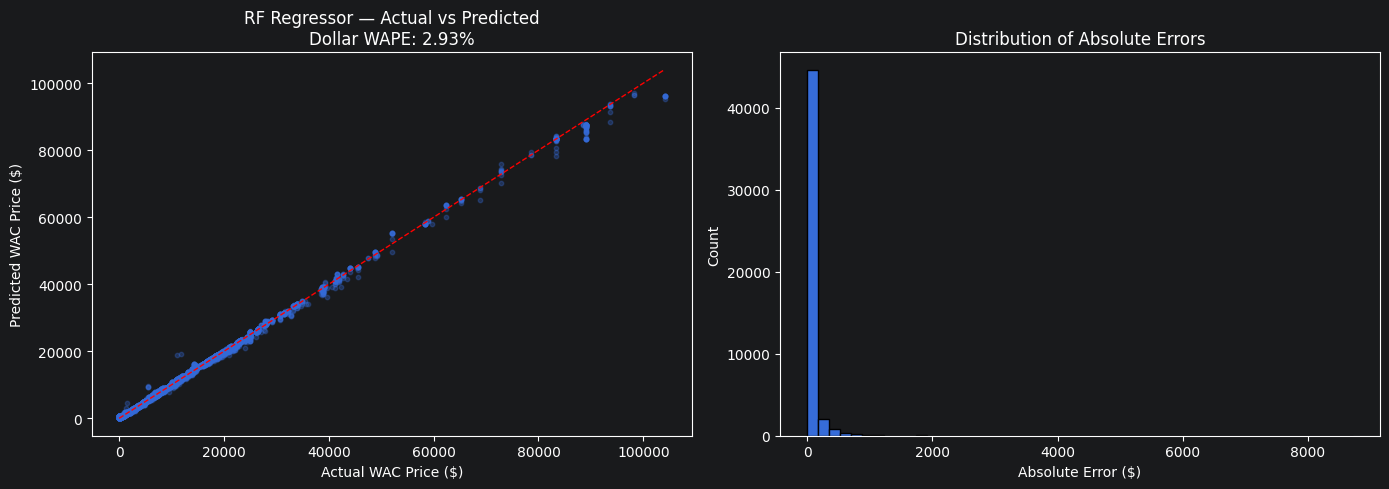

In [21]:
import numpy as np

y_reg_pred = rf_regressor.predict(X_reg_test)

# Dollar WAPE = SUM(|actual - predicted|) / SUM(actual)
dollar_wape = np.sum(np.abs(y_reg_test.values - y_reg_pred)) / np.sum(np.abs(y_reg_test.values))
print(f"Dollar WAPE : {dollar_wape:.4f}  ({dollar_wape*100:.2f}%)")

abs_errors = np.abs(y_reg_test.values - y_reg_pred)
print(f"Median |error| : ${np.median(abs_errors):.2f}")
print(f"Mean   |error| : ${np.mean(abs_errors):.2f}")
print(f"Max    |error| : ${np.max(abs_errors):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_reg_test, y_reg_pred, alpha=0.3, s=10)
axes[0].plot([y_reg_test.min(), y_reg_test.max()],
             [y_reg_test.min(), y_reg_test.max()], "r--", lw=1)
axes[0].set_xlabel("Actual WAC Price ($)")
axes[0].set_ylabel("Predicted WAC Price ($)")
axes[0].set_title(f"RF Regressor — Actual vs Predicted\nDollar WAPE: {dollar_wape*100:.2f}%")

axes[1].hist(abs_errors, bins=50, edgecolor="black")
axes[1].set_xlabel("Absolute Error ($)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Absolute Errors")

plt.tight_layout()
plt.show()

In [22]:
# ── Gradient Boosting Classifier ──
from sklearn.ensemble import HistGradientBoostingClassifier

gbt_classifier = HistGradientBoostingClassifier(
    max_iter=200,
    max_depth=6,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42
)
gbt_classifier.fit(X_train, y_train)
print('GBT Classifier trained.')


GBT Classifier trained.


              precision    recall  f1-score   support

   No Change       0.98      0.90      0.94     43556
Price Change       0.48      0.86      0.62      4729

    accuracy                           0.90     48285
   macro avg       0.73      0.88      0.78     48285
weighted avg       0.93      0.90      0.91     48285



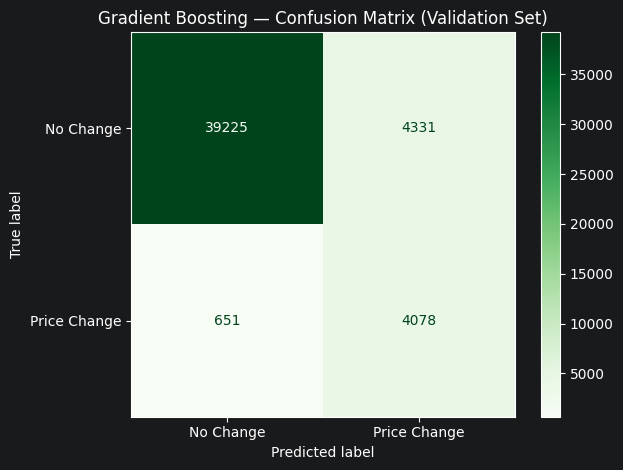

In [23]:
# ── GBT Classifier — evaluation ──
y_gbt_pred = gbt_classifier.predict(X_test)

print(classification_report(y_test, y_gbt_pred, target_names=['No Change', 'Price Change']))

cm_gbt = confusion_matrix(y_test, y_gbt_pred)
disp_gbt = ConfusionMatrixDisplay(confusion_matrix=cm_gbt, display_labels=['No Change', 'Price Change'])
disp_gbt.plot(cmap='Greens')
plt.title('Gradient Boosting — Confusion Matrix (Validation Set)')
plt.tight_layout()
plt.show()


In [24]:
# ── GBT Regressor — CV Grid Search (max_iter x max_depth) ──
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import cross_val_score
import itertools

# Depth 7-8 caused severe overfitting (train MAE $17K vs val $61K).
# Pulling depth back to 4-5 and adding min_samples_leaf to regularize leaf size.
param_grid = {
    'max_iter':         [200, 500],
    'max_depth':        [4, 5],
    'learning_rate':    [0.01, 0.05],
    'min_samples_leaf': [20, 50],
}

cv_results = []
for max_iter, max_depth, lr, msl in itertools.product(
        param_grid['max_iter'], param_grid['max_depth'],
        param_grid['learning_rate'], param_grid['min_samples_leaf']):
    model = HistGradientBoostingRegressor(
        max_iter=max_iter, max_depth=max_depth,
        learning_rate=lr, min_samples_leaf=msl, random_state=42
    )
    scores = cross_val_score(model, X_reg_train, y_reg_train,
                              cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
    mae = -scores.mean()
    cv_results.append({
        'max_iter': max_iter, 'max_depth': max_depth,
        'learning_rate': lr, 'min_samples_leaf': msl,
        'CV_MAE': round(mae, 4), 'CV_MAE_std': round(scores.std(), 4)
    })
    print(f'  iter={max_iter}  depth={max_depth}  lr={lr}  msl={msl}  CV MAE={mae:.4f} ± {scores.std():.4f}')

cv_df = pd.DataFrame(cv_results).sort_values('CV_MAE')
print('\n── Grid Search Results (sorted by CV MAE) ──')
print(cv_df.to_string(index=False))

best = cv_df.iloc[0]
best_max_iter       = int(best['max_iter'])
best_max_depth      = int(best['max_depth'])
best_lr             = float(best['learning_rate'])
best_min_samples    = int(best['min_samples_leaf'])
print(f'\nBest params: max_iter={best_max_iter}, max_depth={best_max_depth}, lr={best_lr}, min_samples_leaf={best_min_samples}  (CV MAE={best["CV_MAE"]})')


  iter=200  depth=4  lr=0.01  msl=20  CV MAE=466.0792 ± 64.3957
  iter=200  depth=4  lr=0.01  msl=50  CV MAE=460.2549 ± 55.8479
  iter=200  depth=4  lr=0.05  msl=20  CV MAE=116.5296 ± 43.7580
  iter=200  depth=4  lr=0.05  msl=50  CV MAE=97.9133 ± 35.5897
  iter=200  depth=5  lr=0.01  msl=20  CV MAE=456.0269 ± 56.0337
  iter=200  depth=5  lr=0.01  msl=50  CV MAE=455.7721 ± 52.5168
  iter=200  depth=5  lr=0.05  msl=20  CV MAE=109.1495 ± 38.9256
  iter=200  depth=5  lr=0.05  msl=50  CV MAE=97.1959 ± 35.4389
  iter=500  depth=4  lr=0.01  msl=20  CV MAE=127.4111 ± 48.4643
  iter=500  depth=4  lr=0.01  msl=50  CV MAE=111.0583 ± 40.0733
  iter=500  depth=4  lr=0.05  msl=20  CV MAE=117.0663 ± 44.0691
  iter=500  depth=4  lr=0.05  msl=50  CV MAE=98.2105 ± 33.1137
  iter=500  depth=5  lr=0.01  msl=20  CV MAE=114.6816 ± 37.6642
  iter=500  depth=5  lr=0.01  msl=50  CV MAE=111.4158 ± 38.2907
  iter=500  depth=5  lr=0.05  msl=20  CV MAE=109.6319 ± 39.3033
  iter=500  depth=5  lr=0.05  msl=50  CV MA

In [25]:
# ── Gradient Boosting Regressor — fit with best CV params ──
from sklearn.ensemble import HistGradientBoostingRegressor

gbt_regressor = HistGradientBoostingRegressor(
    max_iter=best_max_iter,
    max_depth=best_max_depth,
    learning_rate=best_lr,
    min_samples_leaf=best_min_samples,
    random_state=42
)
gbt_regressor.fit(X_reg_train, y_reg_train)
print(f'GBT Regressor trained  (max_iter={best_max_iter}, max_depth={best_max_depth}, lr={best_lr}, min_samples_leaf={best_min_samples}).')


GBT Regressor trained  (max_iter=200, max_depth=5, lr=0.05, min_samples_leaf=50).


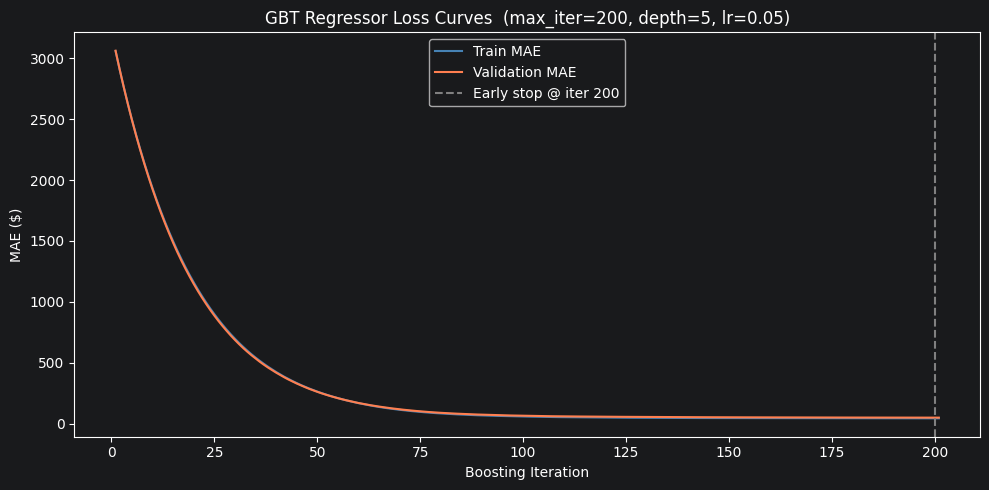

Iterations run: 200 / 200
Final Train MAE: $42.49
Final Val   MAE: $48.25
Train/Val gap:   $5.77  (looks healthy)


In [26]:
# ── GBT Regressor — Loss Curves (train vs validation) to diagnose overfitting ──
# Refit best model with early_stopping enabled so sklearn tracks per-iteration scores
gbt_loss_model = HistGradientBoostingRegressor(
    max_iter=best_max_iter,
    max_depth=best_max_depth,
    learning_rate=best_lr,
    min_samples_leaf=best_min_samples,
    early_stopping=True,
    scoring='neg_mean_absolute_error',
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=42
)
gbt_loss_model.fit(X_reg_train, y_reg_train)

# train_score_/validation_score_ store -MAE per iteration (because scoring='neg_mean_absolute_error')
train_scores = gbt_loss_model.train_score_
val_scores   = gbt_loss_model.validation_score_
iters = range(1, len(train_scores) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(iters, -train_scores, label='Train MAE',      color='steelblue', linewidth=1.5)
ax.plot(iters, -val_scores,   label='Validation MAE', color='coral',     linewidth=1.5)
ax.axvline(gbt_loss_model.n_iter_, color='grey', linestyle='--',
           label=f'Early stop @ iter {gbt_loss_model.n_iter_}')
ax.set_xlabel('Boosting Iteration')
ax.set_ylabel('MAE ($)')
ax.set_title(f'GBT Regressor Loss Curves  '
             f'(max_iter={best_max_iter}, depth={best_max_depth}, lr={best_lr})')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Iterations run: {gbt_loss_model.n_iter_} / {best_max_iter}')
print(f'Final Train MAE: ${-train_scores[-1]:,.2f}')
print(f'Final Val   MAE: ${-val_scores[-1]:,.2f}')
gap = (-val_scores[-1]) - (-train_scores[-1])
print(f'Train/Val gap:   ${gap:,.2f}  ({"likely overfitting" if gap > 500 else "looks healthy"})')


GBT Dollar WAPE : 0.0382  (3.82%)
RF  Dollar WAPE : 0.0293  (2.93%)
Median |error| : $11.37
Mean   |error| : $97.15
Max    |error| : $29697.87


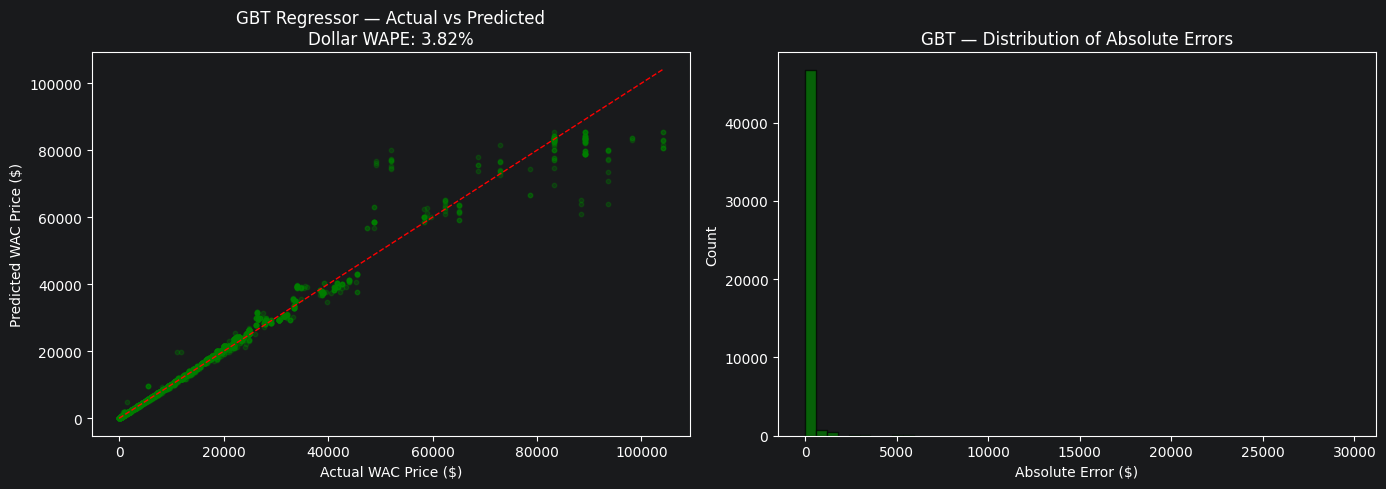

In [27]:
# ── GBT Regressor — evaluation ──
y_gbt_reg_pred = gbt_regressor.predict(X_reg_test)

gbt_dollar_wape = np.sum(np.abs(y_reg_test.values - y_gbt_reg_pred)) / np.sum(np.abs(y_reg_test.values))
rf_dollar_wape  = np.sum(np.abs(y_reg_test.values - y_reg_pred))     / np.sum(np.abs(y_reg_test.values))
print(f'GBT Dollar WAPE : {gbt_dollar_wape:.4f}  ({gbt_dollar_wape*100:.2f}%)')
print(f'RF  Dollar WAPE : {rf_dollar_wape:.4f}  ({rf_dollar_wape*100:.2f}%)')

gbt_abs_errors = np.abs(y_reg_test.values - y_gbt_reg_pred)
print(f'Median |error| : ${np.median(gbt_abs_errors):.2f}')
print(f'Mean   |error| : ${np.mean(gbt_abs_errors):.2f}')
print(f'Max    |error| : ${np.max(gbt_abs_errors):.2f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_reg_test, y_gbt_reg_pred, alpha=0.3, s=10, color='green')
axes[0].plot([y_reg_test.min(), y_reg_test.max()],
             [y_reg_test.min(), y_reg_test.max()], 'r--', lw=1)
axes[0].set_xlabel('Actual WAC Price ($)')
axes[0].set_ylabel('Predicted WAC Price ($)')
axes[0].set_title(f'GBT Regressor — Actual vs Predicted\nDollar WAPE: {gbt_dollar_wape*100:.2f}%')

axes[1].hist(gbt_abs_errors, bins=50, edgecolor='black', color='green', alpha=0.7)
axes[1].set_xlabel('Absolute Error ($)')
axes[1].set_ylabel('Count')
axes[1].set_title('GBT — Distribution of Absolute Errors')

plt.tight_layout()
plt.show()


In [28]:
# ── GBT — Top-500 Revenue Products: data prep & WAPE computation ──
import matplotlib.cm as cm
from matplotlib.patches import Patch

top500_gbt = pd.read_csv('../data/real_data/Top_500_revenueproducts.csv', dtype=str)
top500_gbt['ACTUAL_WAC']     = top500_gbt['ACTUAL_WAC'].astype(float)
top500_gbt['FORECASTED_WAC'] = top500_gbt['FORECASTED_WAC'].astype(float)
top500_gbt['REVENUE_RANK']   = top500_gbt['REVENUE_RANK'].astype(int)

# Use only the Jan-2024 baseline run — BT_2024_04 / BT_2025_01 are re-forecasts
top500_gbt = top500_gbt[top500_gbt['RUN_ID'] == 'BT_2024_01'].copy()

mat_meta_gbt = (
    top500_gbt[['MTRL_NUM','MATERIAL_NAME','CUST_PROD_CATEGORY','REVENUE_RANK','THERAPEUTIC_CLASS','MANUFACTURER_NAME']]
    .sort_values('REVENUE_RANK')
    .drop_duplicates(subset='MTRL_NUM')
    .reset_index(drop=True)
)

eval_df_gbt = reg_test_full.dropna(subset=['TGT_NEXT_MONTH_WAC']).copy().reset_index(drop=True)
eval_df_gbt['GBT_PREDICTED_WAC']  = y_gbt_reg_pred
eval_df_gbt['COPA_MTRL_NUM']       = eval_df_gbt['COPA_MTRL_NUM'].astype(str).str.zfill(18)
eval_df_gbt['WAC_PRICE_COPA_DATE'] = pd.to_datetime(eval_df_gbt['WAC_PRICE_COPA_DATE']).dt.strftime('%Y-%m-%d')
eval_df_gbt['ACTUAL_WAC']          = y_reg_test.values

# Shift FORECAST_MONTH back 1 month: baseline predicts month T+1,
# but the model row is dated T — align on the prediction period
top500_gbt_join = top500_gbt[['MTRL_NUM','FORECAST_MONTH','FORECASTED_WAC']].copy()
top500_gbt_join['FORECAST_MONTH'] = (
    pd.to_datetime(top500_gbt_join['FORECAST_MONTH']) - pd.DateOffset(months=1)
).dt.strftime('%Y-%m-%d')
rf_eval_gbt = eval_df_gbt.merge(
    top500_gbt_join.rename(columns={'MTRL_NUM':'COPA_MTRL_NUM', 'FORECAST_MONTH':'WAC_PRICE_COPA_DATE'}),
    on=['COPA_MTRL_NUM','WAC_PRICE_COPA_DATE'], how='inner'
)

print(f'Top-500 materials matched in GBT validation : {rf_eval_gbt["COPA_MTRL_NUM"].nunique()} of {mat_meta_gbt.shape[0]}')
print(f'Material-month rows                         : {len(rf_eval_gbt):,}')

def dollar_wape_gbt(actual, predicted):
    return np.sum(np.abs(actual - predicted)) / np.sum(np.abs(actual))

records_gbt = []
for mtrl, grp in rf_eval_gbt.groupby('COPA_MTRL_NUM'):
    act  = grp['ACTUAL_WAC'].values
    gbt  = grp['GBT_PREDICTED_WAC'].values
    base = grp['FORECASTED_WAC'].values
    records_gbt.append({
        'COPA_MTRL_NUM'        : mtrl,
        'GBT_DOLLAR_WAPE'      : dollar_wape_gbt(act, gbt),
        'BASELINE_DOLLAR_WAPE' : dollar_wape_gbt(act, base),
        'N_MONTHS'             : len(grp),
    })

per_mat_gbt = (
    pd.DataFrame(records_gbt)
    .merge(mat_meta_gbt.rename(columns={'MTRL_NUM':'COPA_MTRL_NUM'}), on='COPA_MTRL_NUM')
    .sort_values('REVENUE_RANK')
    .reset_index(drop=True)
)
per_mat_gbt['WAPE_IMPROVEMENT'] = per_mat_gbt['BASELINE_DOLLAR_WAPE'] - per_mat_gbt['GBT_DOLLAR_WAPE']

overall_gbt  = dollar_wape_gbt(rf_eval_gbt['ACTUAL_WAC'].values, rf_eval_gbt['GBT_PREDICTED_WAC'].values)
overall_base_gbt = dollar_wape_gbt(rf_eval_gbt['ACTUAL_WAC'].values, rf_eval_gbt['FORECASTED_WAC'].values)
print(f'\nOverall Dollar WAPE — GBT Model : {overall_gbt*100:.2f}%')
print(f'Overall Dollar WAPE — Baseline  : {overall_base_gbt*100:.2f}%')
print(f'Improvement                     : {(overall_base_gbt - overall_gbt)*100:.2f} pp')
print()
display(per_mat_gbt[['REVENUE_RANK','MATERIAL_NAME','CUST_PROD_CATEGORY',
                      'GBT_DOLLAR_WAPE','BASELINE_DOLLAR_WAPE','WAPE_IMPROVEMENT','N_MONTHS']]
        .round(4).reset_index(drop=True))


Top-500 materials matched in GBT validation : 379 of 425
Material-month rows                         : 4,706

Overall Dollar WAPE — GBT Model : 2.44%
Overall Dollar WAPE — Baseline  : 3.25%
Improvement                     : 0.81 pp



,REVENUE_RANK,MATERIAL_NAME,CUST_PROD_CATEGORY,GBT_DOLLAR_WAPE,BASELINE_DOLLAR_WAPE,WAPE_IMPROVEMENT,N_MONTHS
0,1,HUMIRA CF PEN 40MG/0.4ML 2,APOLLO,0.0113,0.0776,0.0663,12
1,2,ELIQUIS TAB 5MG 60,BX,0.0156,0.0575,0.0419,21
2,3,STELARA PFS 90MG/1.0ML 1,APOLLO,0.0101,0.0039,-0.0062,12
3,4,DUPIXENT INJ 300MG/2ML 2,APOLLO,0.0053,0.0471,0.0419,12
4,5,SKYRIZI INJ150MG/ML SD PEN,APOLLO,0.0305,0.0119,-0.0186,12
...,...,...,...,...,...,...,...
374,496,XIFAXAN TAB 550MG UD 60,BX,0.0167,0.0371,0.0203,12
375,497,ARISTADA 882MG PFS 1,BX,0.0093,0.0274,0.0181,12
376,498,LUPRON DEPOT GYN 11.25MG 1,APOLLO,0.0264,0.0152,-0.0112,12
377,499,ALDURAZYME VL 2.9MG/5ML D/S 1,DROP SHIP,0.0069,0.0028,-0.0041,17


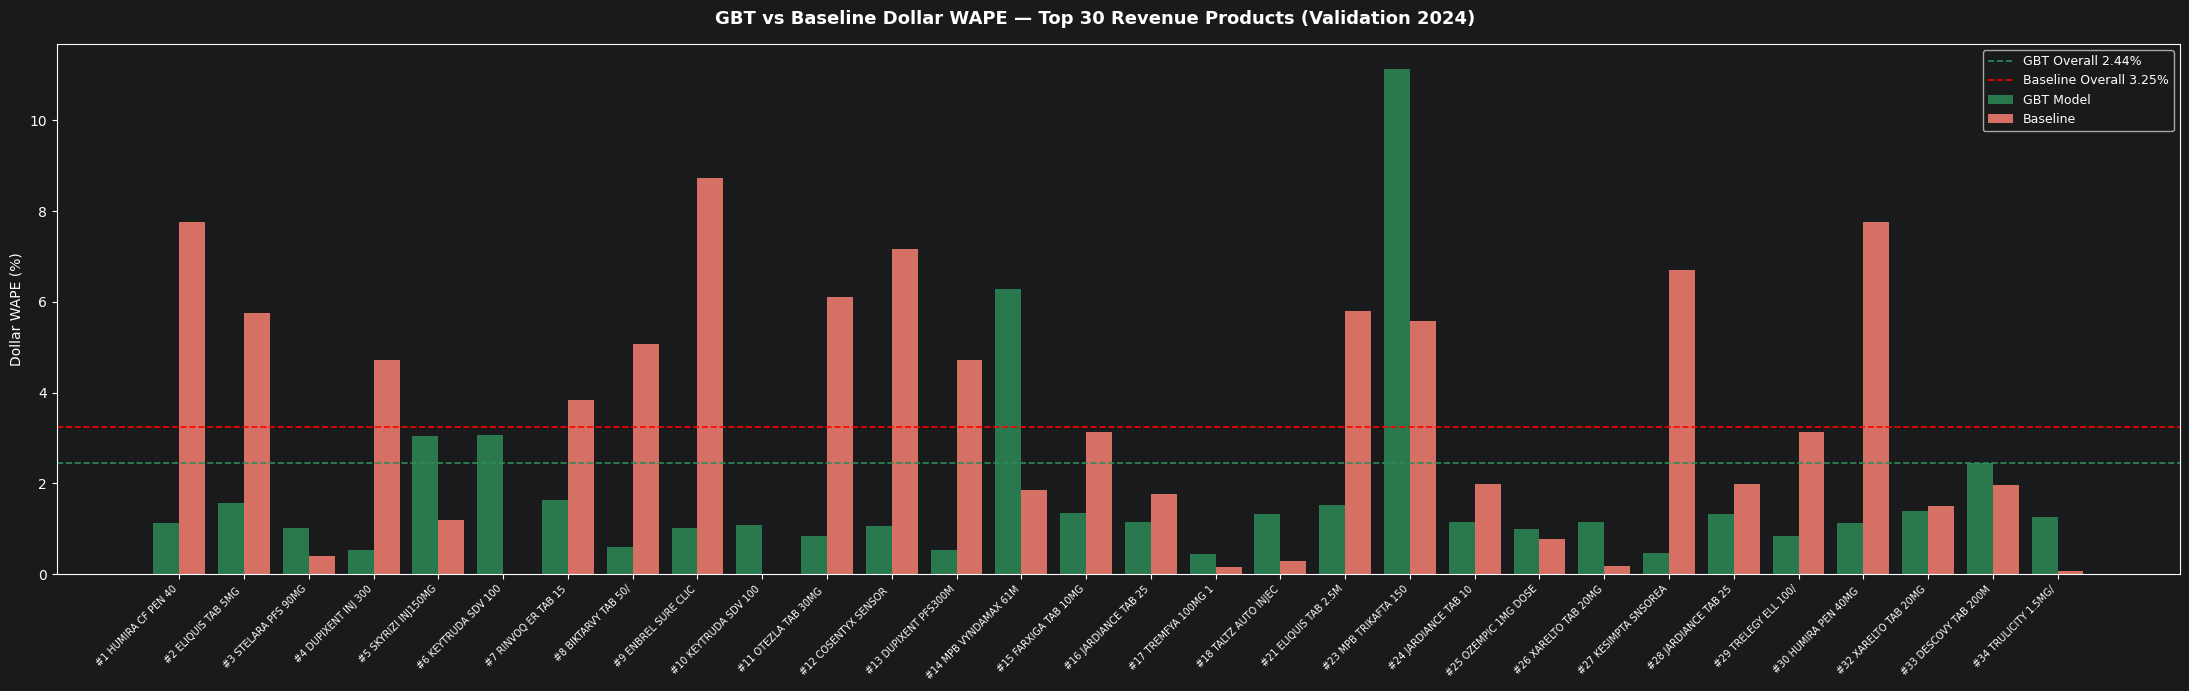

In [29]:
# ── GBT — Plot 1: Grouped bar — GBT vs Baseline Dollar WAPE (top 30) ──
top_n_gbt = per_mat_gbt.head(30).copy()
x_gbt     = np.arange(len(top_n_gbt))
width_gbt = 0.4
cats_gbt       = per_mat_gbt['CUST_PROD_CATEGORY'].unique()
cat_colors_gbt = {c: cm.tab10(i/max(len(cats_gbt)-1,1)) for i, c in enumerate(sorted(cats_gbt))}

fig, ax = plt.subplots(figsize=(22, 7))
fig.suptitle('GBT vs Baseline Dollar WAPE — Top 30 Revenue Products (Validation 2024)',
             fontweight='bold', fontsize=13)
ax.bar(x_gbt - width_gbt/2, top_n_gbt['GBT_DOLLAR_WAPE']*100,       width_gbt, label='GBT Model', color='seagreen',  alpha=0.85)
ax.bar(x_gbt + width_gbt/2, top_n_gbt['BASELINE_DOLLAR_WAPE']*100,  width_gbt, label='Baseline',  color='salmon',    alpha=0.85)
ax.axhline(overall_gbt*100,      color='seagreen', linestyle='--', linewidth=1.2, label=f'GBT Overall {overall_gbt*100:.2f}%')
ax.axhline(overall_base_gbt*100, color='red',      linestyle='--', linewidth=1.2, label=f'Baseline Overall {overall_base_gbt*100:.2f}%')
ax.set_xticks(x_gbt)
xlabels_gbt = top_n_gbt.apply(lambda r: f"#{int(r['REVENUE_RANK'])} {r['MATERIAL_NAME'][:16]}", axis=1)
ax.set_xticklabels(xlabels_gbt, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Dollar WAPE (%)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


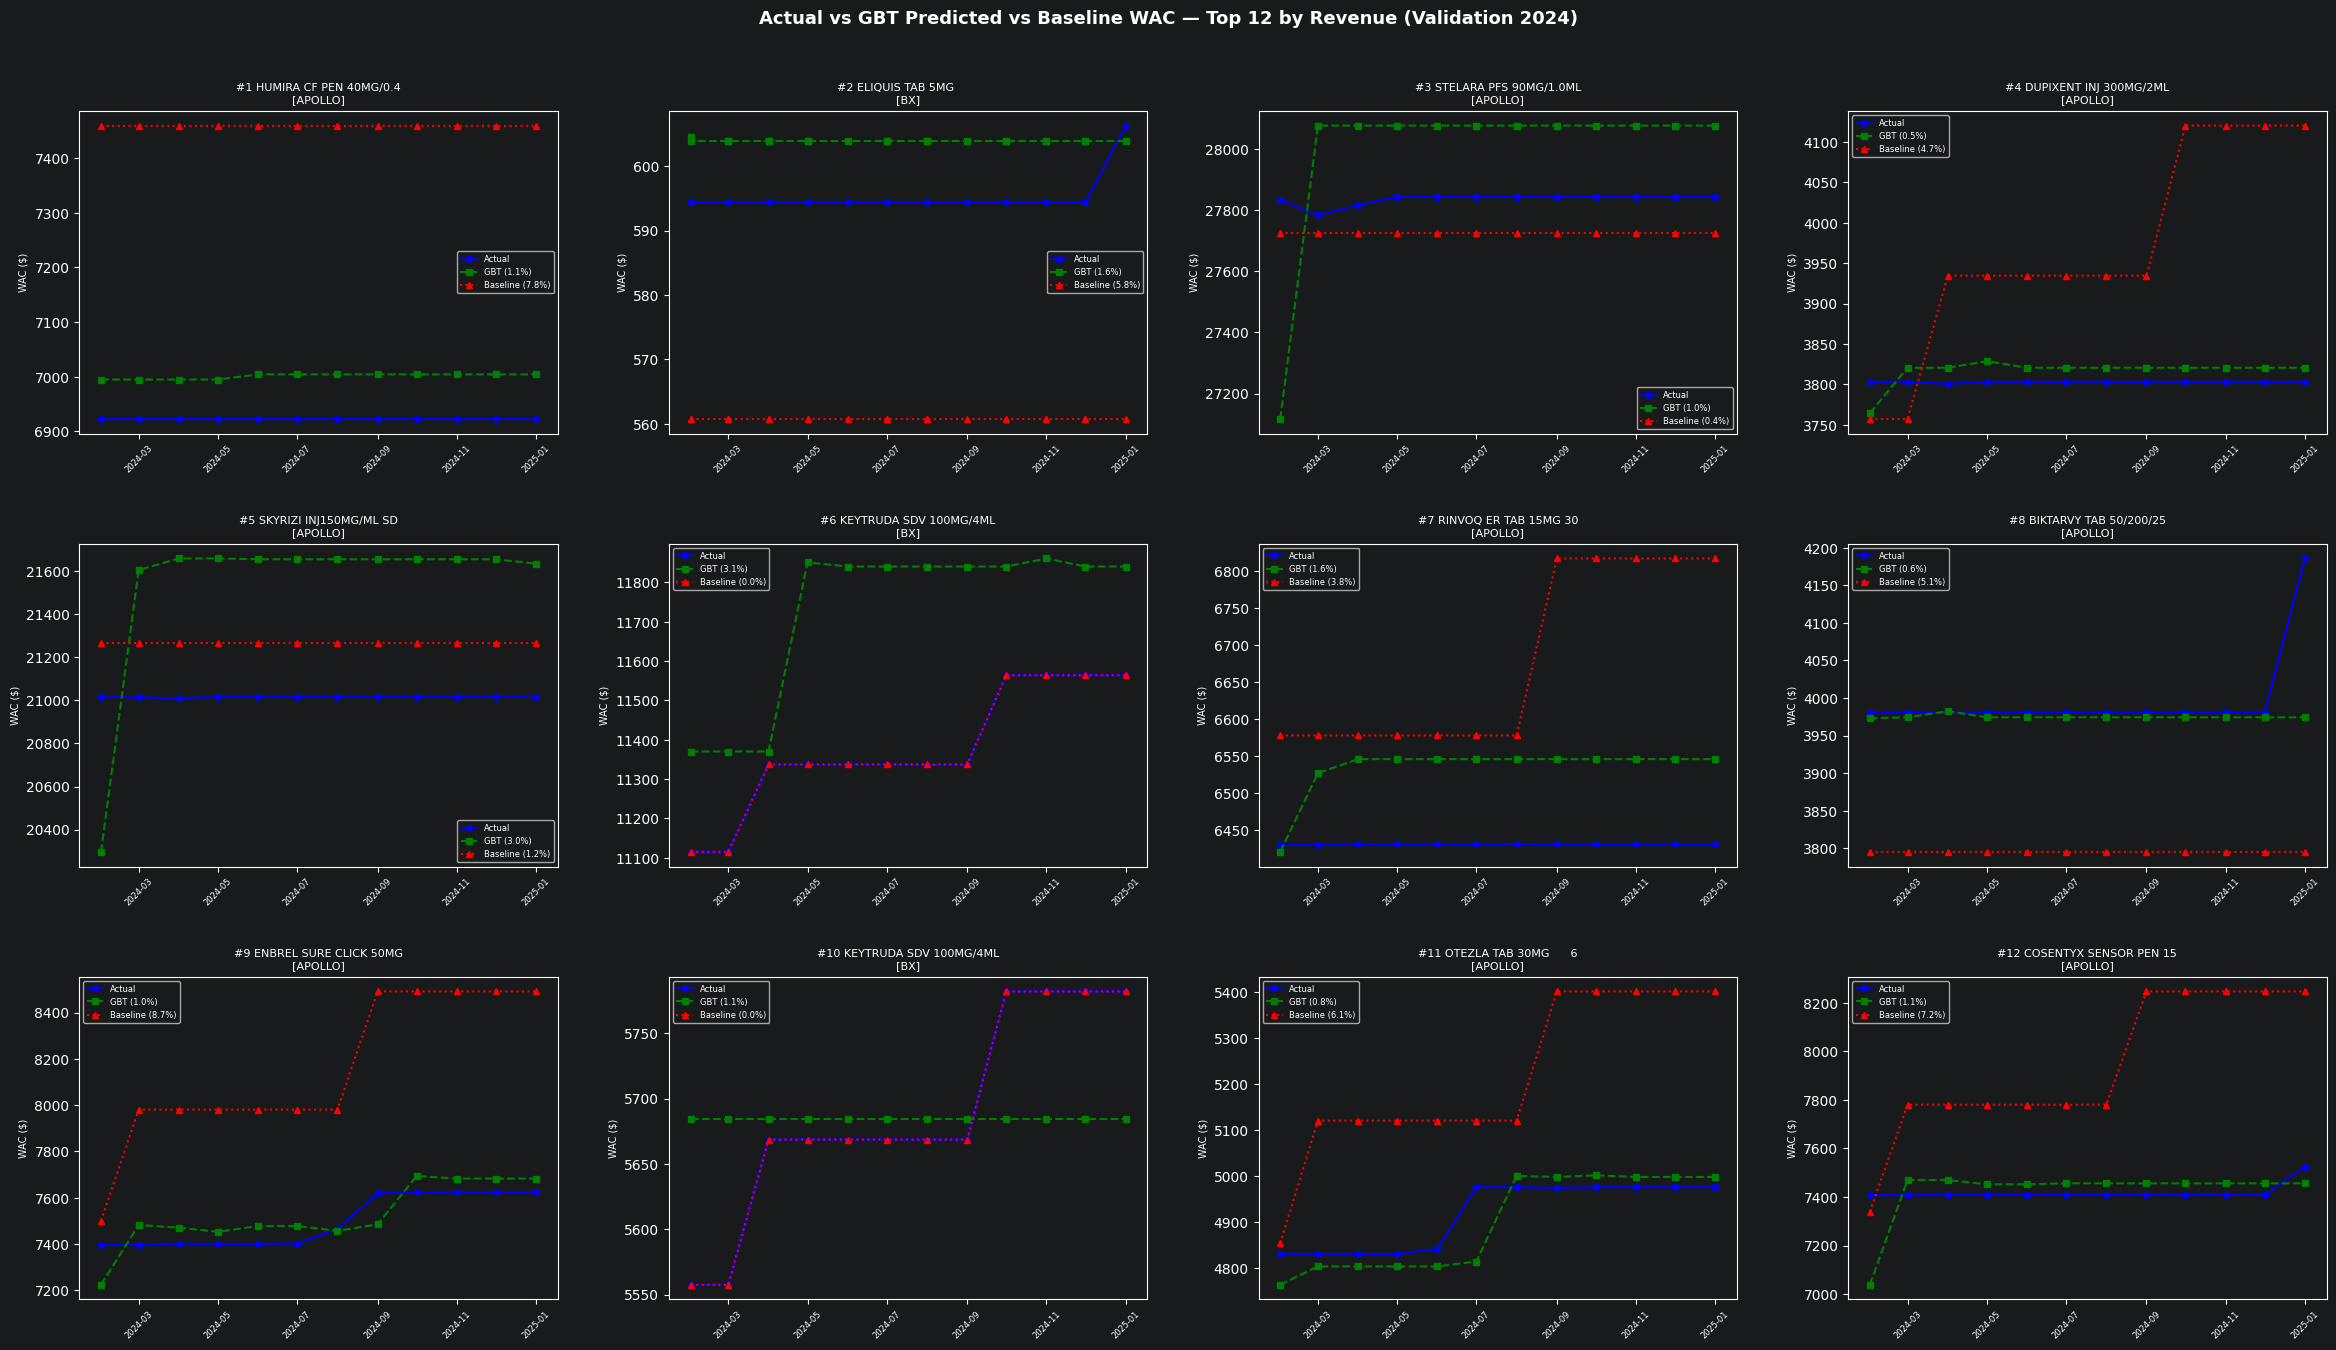

In [30]:
# ── GBT — Plot 2: Actual vs GBT vs Baseline time-series — top 12 by revenue ──
top12_gbt = per_mat_gbt.head(12).reset_index(drop=True)
fig, axes = plt.subplots(3, 4, figsize=(24, 14))
fig.suptitle('Actual vs GBT Predicted vs Baseline WAC — Top 12 by Revenue (Validation 2024)',
             fontweight='bold', fontsize=13)
axes = axes.flatten()

for i, row in top12_gbt.iterrows():
    mtrl   = row['COPA_MTRL_NUM']
    subset = rf_eval_gbt[rf_eval_gbt['COPA_MTRL_NUM'] == mtrl].sort_values('WAC_PRICE_COPA_DATE')
    ax     = axes[i]
    dates  = pd.to_datetime(subset['WAC_PRICE_COPA_DATE']) + pd.DateOffset(months=1)  # shift to predicted month
    ax.plot(dates, subset['ACTUAL_WAC'],          'b-o',  markersize=4, label='Actual')
    ax.plot(dates, subset['GBT_PREDICTED_WAC'],   'g--s', markersize=4, label=f"GBT ({row['GBT_DOLLAR_WAPE']*100:.1f}%)")
    ax.plot(dates, subset['FORECASTED_WAC'],       'r:^',  markersize=4, label=f"Baseline ({row['BASELINE_DOLLAR_WAPE']*100:.1f}%)")
    ax.set_title(f"#{int(row['REVENUE_RANK'])} {row['MATERIAL_NAME'][:22]}\n"
                 f"[{row['CUST_PROD_CATEGORY']}]", fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=6)
    ax.set_ylabel('WAC ($)', fontsize=7)
    ax.legend(fontsize=6)

plt.tight_layout(pad=3.0)
plt.show()


In [31]:
# ── Top-500 Revenue Products: data prep & WAPE computation ──
import matplotlib.cm as cm
from matplotlib.patches import Patch

# Load Top_500_revenueproducts (445 unique materials, has baseline FORECASTED_WAC)
top500 = pd.read_csv('../data/real_data/Top_500_revenueproducts.csv', dtype=str)
top500['ACTUAL_WAC']     = top500['ACTUAL_WAC'].astype(float)
top500['FORECASTED_WAC'] = top500['FORECASTED_WAC'].astype(float)
top500['REVENUE_RANK']   = top500['REVENUE_RANK'].astype(int)

# Use only the Jan-2024 baseline run — BT_2024_04 / BT_2025_01 are re-forecasts
top500     = top500[top500['RUN_ID'] == 'BT_2024_01'].copy()

# Material metadata (one row per material, keep best rank)
mat_meta = (
    top500[['MTRL_NUM','MATERIAL_NAME','CUST_PROD_CATEGORY','REVENUE_RANK','THERAPEUTIC_CLASS','MANUFACTURER_NAME']]
    .sort_values('REVENUE_RANK')
    .drop_duplicates(subset='MTRL_NUM')
    .reset_index(drop=True)
)

# ── Build RF evaluation frame from reg_test_full ──
eval_df = reg_test_full.dropna(subset=['TGT_NEXT_MONTH_WAC']).copy()
eval_df = eval_df.reset_index(drop=True)
eval_df['RF_PREDICTED_WAC'] = y_reg_pred
eval_df['COPA_MTRL_NUM']    = eval_df['COPA_MTRL_NUM'].astype(str).str.zfill(18)
eval_df['WAC_PRICE_COPA_DATE'] = pd.to_datetime(eval_df['WAC_PRICE_COPA_DATE']).dt.strftime('%Y-%m-%d')
eval_df['ACTUAL_WAC']       = y_reg_test.values

# Join RF predictions to top500 on MTRL_NUM + date
# Shift FORECAST_MONTH back 1 month: baseline predicts month T+1,
# but the model row is dated T — align on the prediction period
top500_join = top500[['MTRL_NUM','FORECAST_MONTH','FORECASTED_WAC']].copy()
top500_join['FORECAST_MONTH'] = (
    pd.to_datetime(top500_join['FORECAST_MONTH']) - pd.DateOffset(months=1)
).dt.strftime('%Y-%m-%d')
rf_eval = eval_df.merge(
    top500_join.rename(columns={'MTRL_NUM':'COPA_MTRL_NUM', 'FORECAST_MONTH':'WAC_PRICE_COPA_DATE'}),
    on=['COPA_MTRL_NUM','WAC_PRICE_COPA_DATE'], how='inner'
)

print(f'Top-500 materials matched in RF validation : {rf_eval["COPA_MTRL_NUM"].nunique()} of {mat_meta.shape[0]}')
print(f'Material-month rows                        : {len(rf_eval):,}')

# ── Dollar WAPE helper ──
def dollar_wape(actual, predicted):
    return np.sum(np.abs(actual - predicted)) / np.sum(np.abs(actual))

# ── Per-material Dollar WAPE: RF model vs Baseline FORECASTED_WAC ──
records = []
for mtrl, grp in rf_eval.groupby('COPA_MTRL_NUM'):
    act  = grp['ACTUAL_WAC'].values
    rf   = grp['RF_PREDICTED_WAC'].values
    base = grp['FORECASTED_WAC'].values
    records.append({
        'COPA_MTRL_NUM'        : mtrl,
        'RF_DOLLAR_WAPE'       : dollar_wape(act, rf),
        'BASELINE_DOLLAR_WAPE' : dollar_wape(act, base),
        'N_MONTHS'             : len(grp),
    })

per_mat = (
    pd.DataFrame(records)
    .merge(mat_meta.rename(columns={'MTRL_NUM':'COPA_MTRL_NUM'}), on='COPA_MTRL_NUM')
    .sort_values('REVENUE_RANK')
    .reset_index(drop=True)
)
per_mat['WAPE_IMPROVEMENT'] = per_mat['BASELINE_DOLLAR_WAPE'] - per_mat['RF_DOLLAR_WAPE']

# Overall
overall_rf   = dollar_wape(rf_eval['ACTUAL_WAC'].values, rf_eval['RF_PREDICTED_WAC'].values)
overall_base = dollar_wape(rf_eval['ACTUAL_WAC'].values, rf_eval['FORECASTED_WAC'].values)
print(f'\nOverall Dollar WAPE — RF Model  : {overall_rf*100:.2f}%')
print(f'Overall Dollar WAPE — Baseline  : {overall_base*100:.2f}%')
print(f'Improvement                     : {(overall_base - overall_rf)*100:.2f} pp')
print()
display(per_mat[['REVENUE_RANK','MATERIAL_NAME','CUST_PROD_CATEGORY',
                 'RF_DOLLAR_WAPE','BASELINE_DOLLAR_WAPE','WAPE_IMPROVEMENT','N_MONTHS']]
        .round(4).reset_index(drop=True))


Top-500 materials matched in RF validation : 379 of 425
Material-month rows                        : 4,706

Overall Dollar WAPE — RF Model  : 1.95%
Overall Dollar WAPE — Baseline  : 3.25%
Improvement                     : 1.30 pp



,REVENUE_RANK,MATERIAL_NAME,CUST_PROD_CATEGORY,RF_DOLLAR_WAPE,BASELINE_DOLLAR_WAPE,WAPE_IMPROVEMENT,N_MONTHS
0,1,HUMIRA CF PEN 40MG/0.4ML 2,APOLLO,0.0094,0.0776,0.0682,12
1,2,ELIQUIS TAB 5MG 60,BX,0.1312,0.0575,-0.0736,21
2,3,STELARA PFS 90MG/1.0ML 1,APOLLO,0.0349,0.0039,-0.0310,12
3,4,DUPIXENT INJ 300MG/2ML 2,APOLLO,0.0193,0.0471,0.0278,12
4,5,SKYRIZI INJ150MG/ML SD PEN,APOLLO,0.0065,0.0119,0.0053,12
...,...,...,...,...,...,...,...
374,496,XIFAXAN TAB 550MG UD 60,BX,0.0125,0.0371,0.0246,12
375,497,ARISTADA 882MG PFS 1,BX,0.0185,0.0274,0.0089,12
376,498,LUPRON DEPOT GYN 11.25MG 1,APOLLO,0.0161,0.0152,-0.0009,12
377,499,ALDURAZYME VL 2.9MG/5ML D/S 1,DROP SHIP,0.0095,0.0028,-0.0067,17


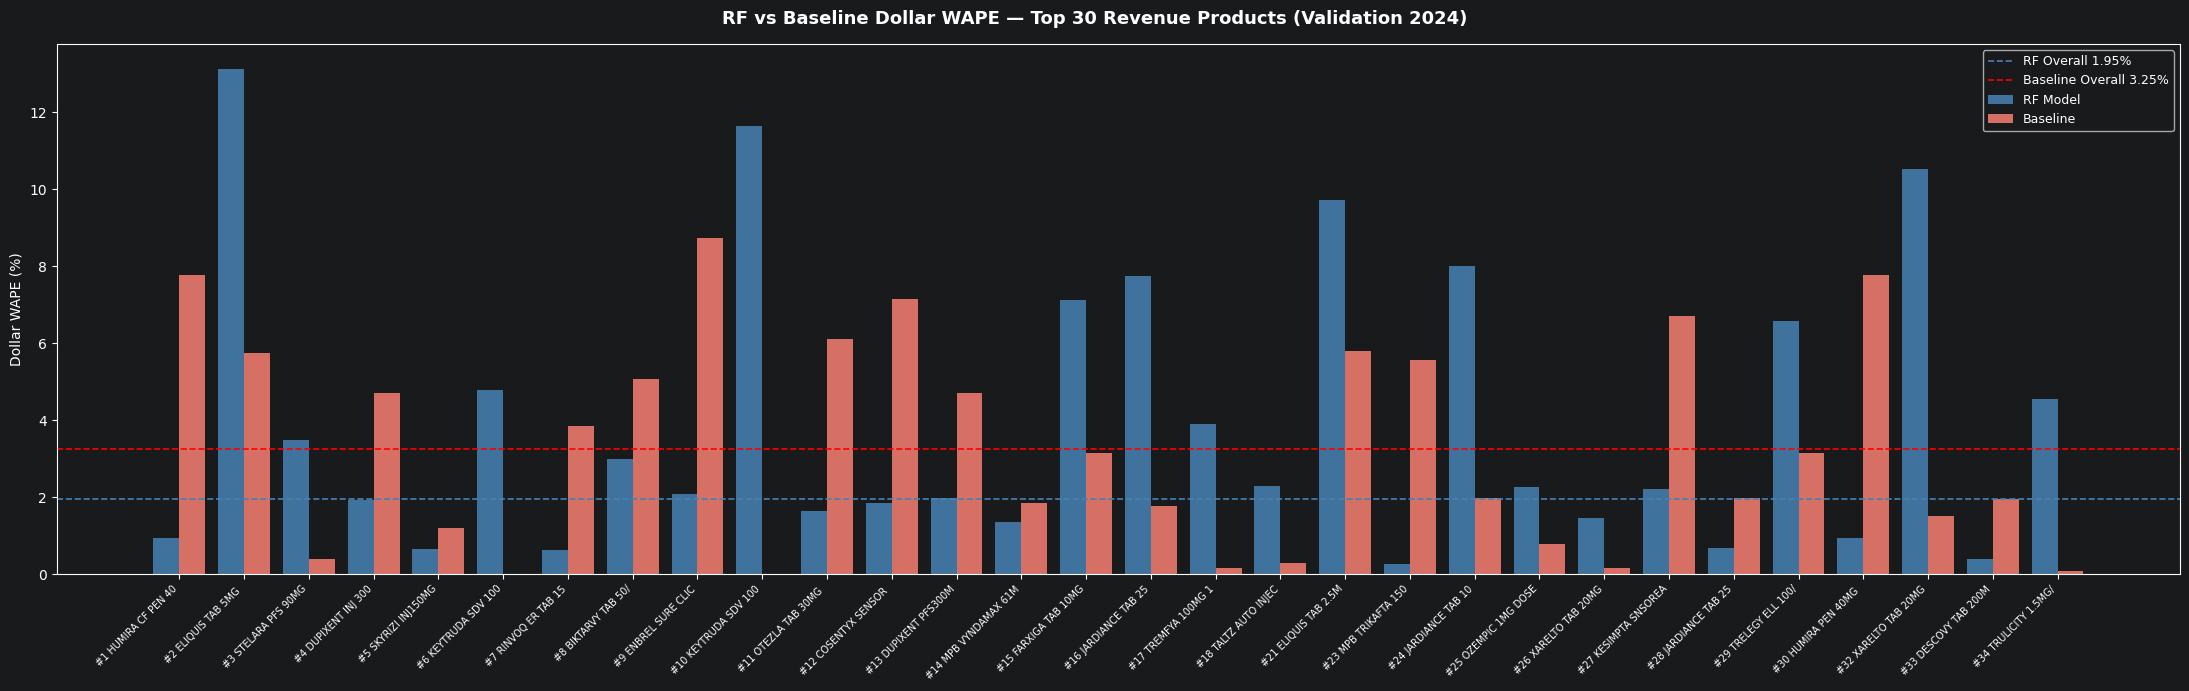

In [32]:
# ── Plot 1: Grouped bar (top 30) + WAPE improvement scatter (all 445) ──
top_n  = per_mat.head(30).copy()
x      = np.arange(len(top_n))
width  = 0.4
cats       = per_mat['CUST_PROD_CATEGORY'].unique()
cat_colors = {c: cm.tab10(i/max(len(cats)-1,1)) for i, c in enumerate(sorted(cats))}

# --- Grouped bar: top 30 ---
fig, ax = plt.subplots(figsize=(22, 7))
fig.suptitle('RF vs Baseline Dollar WAPE — Top 30 Revenue Products (Validation 2024)',
             fontweight='bold', fontsize=13)
ax.bar(x - width/2, top_n['RF_DOLLAR_WAPE']*100,       width, label='RF Model',  color='steelblue', alpha=0.85)
ax.bar(x + width/2, top_n['BASELINE_DOLLAR_WAPE']*100, width, label='Baseline',  color='salmon',    alpha=0.85)
ax.axhline(overall_rf*100,   color='steelblue', linestyle='--', linewidth=1.2, label=f'RF Overall {overall_rf*100:.2f}%')
ax.axhline(overall_base*100, color='red',       linestyle='--', linewidth=1.2, label=f'Baseline Overall {overall_base*100:.2f}%')
ax.set_xticks(x)
xlabels = top_n.apply(lambda r: f"#{int(r['REVENUE_RANK'])} {r['MATERIAL_NAME'][:16]}", axis=1)
ax.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Dollar WAPE (%)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


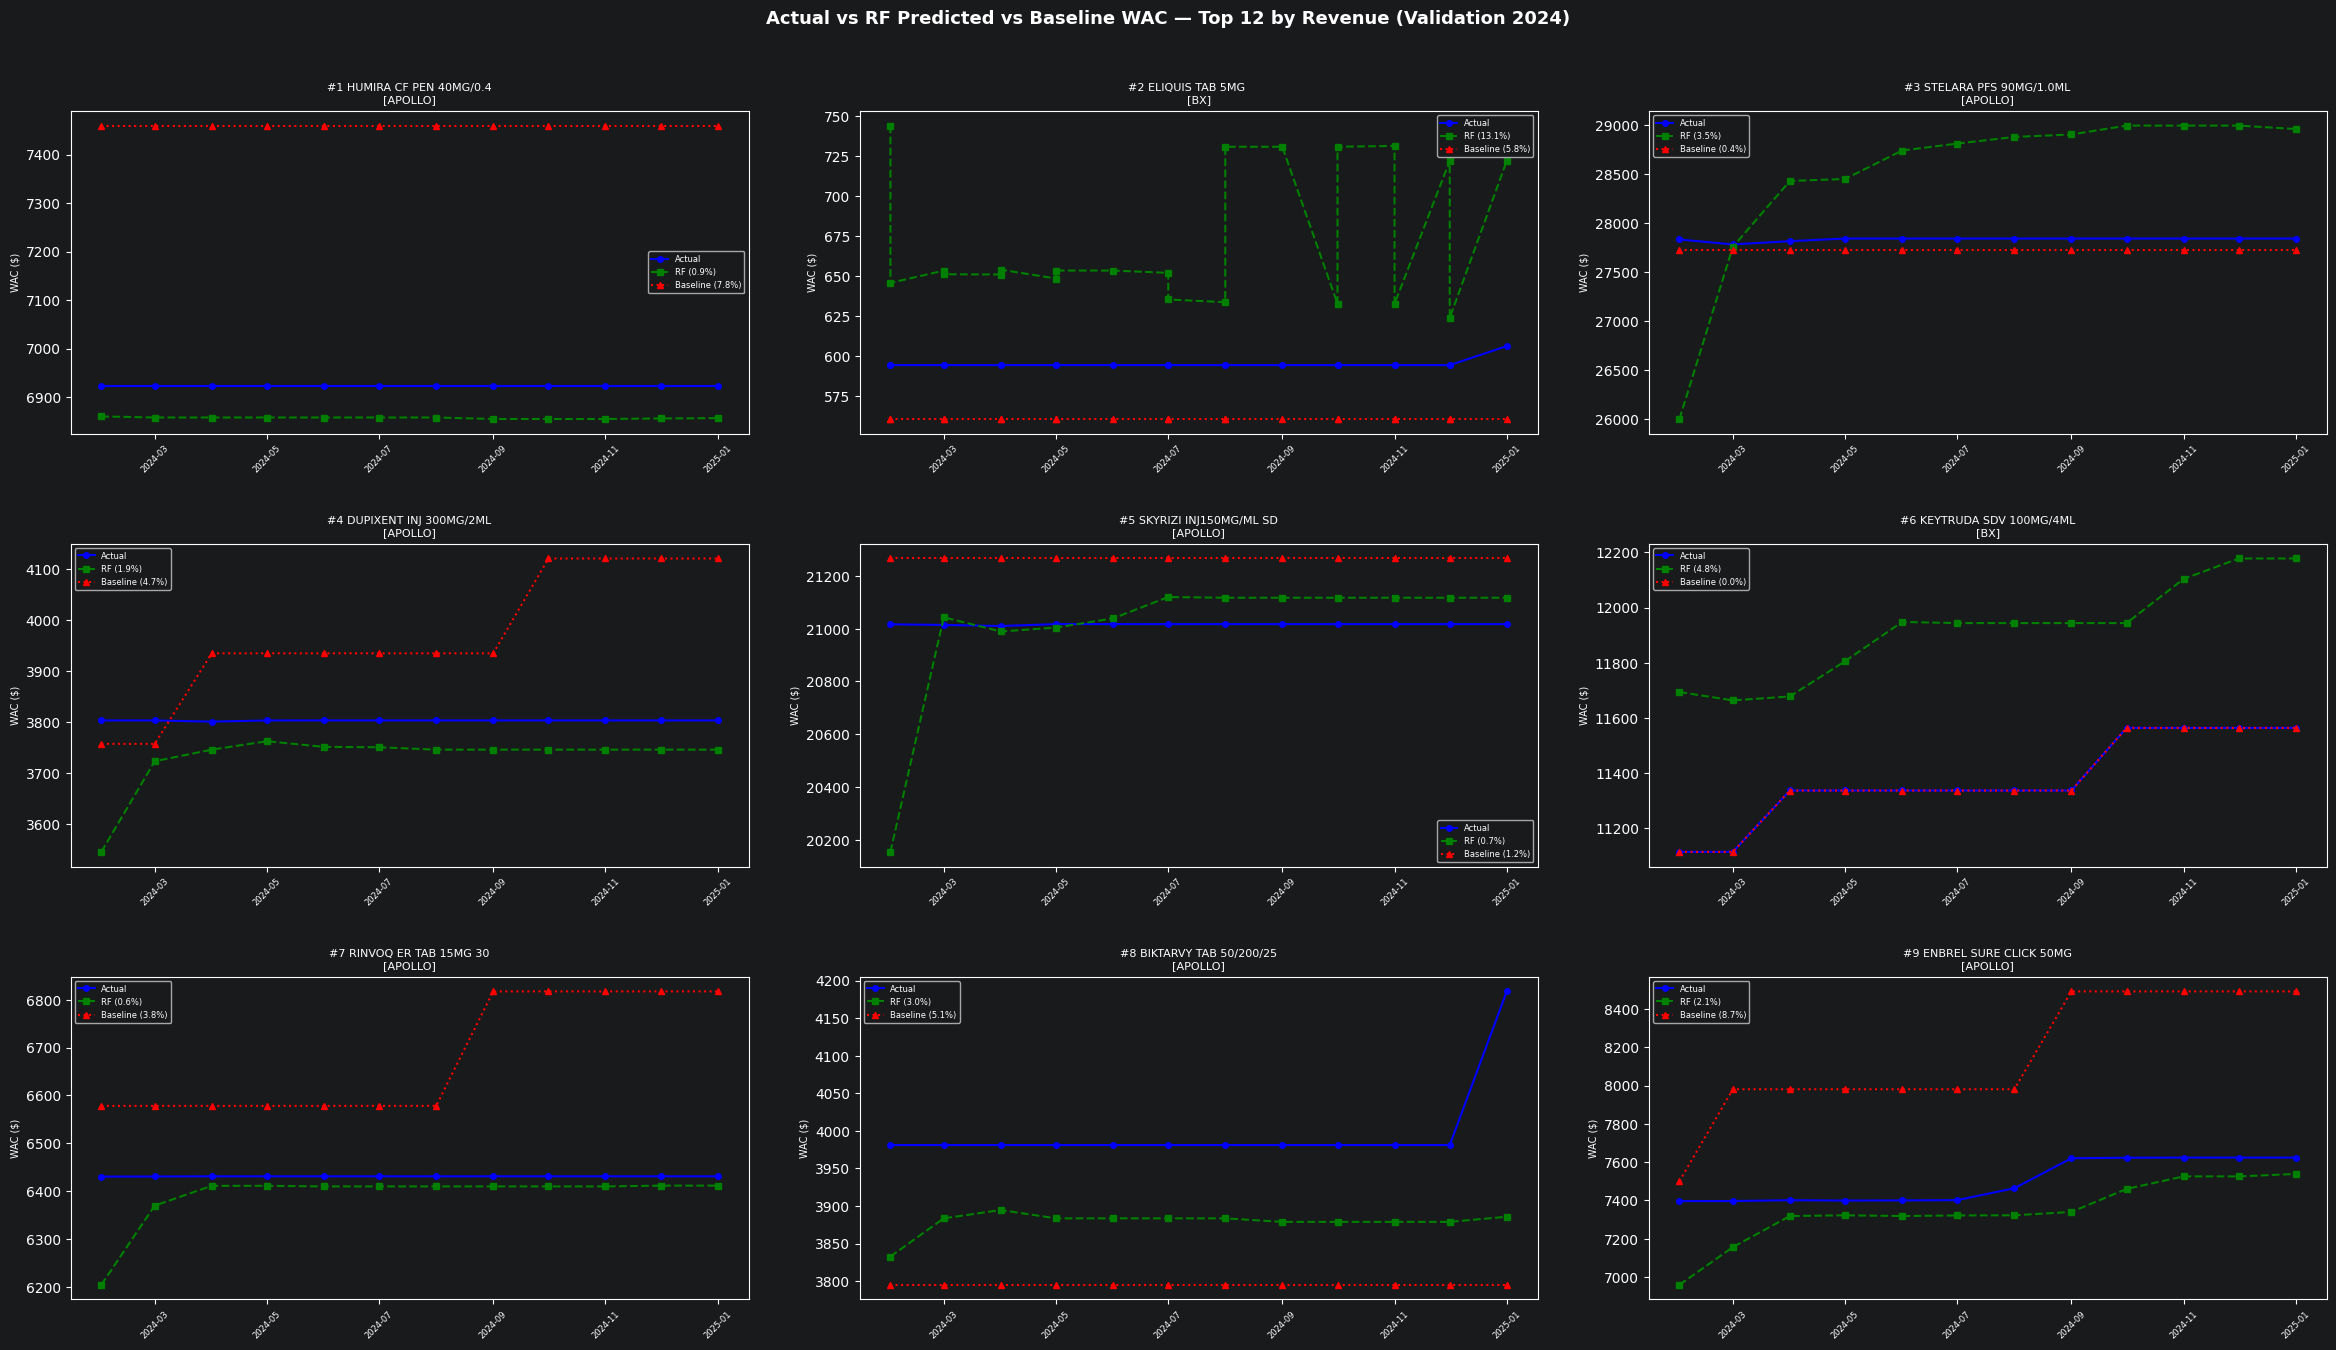

In [33]:
# ── Plot 2: Actual vs RF vs Baseline time-series — top 12 by revenue rank ──
top12 = per_mat.head(9).reset_index(drop=True)
fig, axes = plt.subplots(3, 3, figsize=(24, 14))
fig.suptitle('Actual vs RF Predicted vs Baseline WAC — Top 12 by Revenue (Validation 2024)',
             fontweight='bold', fontsize=13)
axes = axes.flatten()

for i, row in top12.iterrows():
    mtrl   = row['COPA_MTRL_NUM']
    subset = rf_eval[rf_eval['COPA_MTRL_NUM'] == mtrl].sort_values('WAC_PRICE_COPA_DATE')
    ax     = axes[i]
    dates  = pd.to_datetime(subset['WAC_PRICE_COPA_DATE']) + pd.DateOffset(months=1)  # shift to predicted month
    ax.plot(dates, subset['ACTUAL_WAC'],               'b-o',  markersize=4, label='Actual')
    ax.plot(dates, subset['RF_PREDICTED_WAC'], 'g--s', markersize=4, label=f"RF ({row['RF_DOLLAR_WAPE']*100:.1f}%)")
    ax.plot(dates, subset['FORECASTED_WAC'],   'r:^',  markersize=4, label=f"Baseline ({row['BASELINE_DOLLAR_WAPE']*100:.1f}%)")
    ax.set_title(f"#{int(row['REVENUE_RANK'])} {row['MATERIAL_NAME'][:22]}\n"
                 f"[{row['CUST_PROD_CATEGORY']}]", fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=6)
    ax.set_ylabel('WAC ($)', fontsize=7)
    ax.legend(fontsize=6)

plt.tight_layout(pad=3.0)
plt.show()


In [34]:
# ── Final Export: features + targets + predictions ──────────────────────────

# Base rows: regression test set (2024 validation, rows with known next-month WAC)
reg_test_orig_idx = reg_test_full.dropna(subset=['TGT_NEXT_MONTH_WAC']).index
export_df = reg_test_full.loc[reg_test_orig_idx].copy().reset_index(drop=True)

# ── Assign predictions BEFORE any merge (positional alignment) ──
clf_pred_s     = pd.Series(y_pred,     index=validation_split.index)
gbt_clf_pred_s = pd.Series(y_gbt_pred, index=validation_split.index)
export_df['RF_CLF_PRED']  = clf_pred_s.reindex(reg_test_orig_idx).values
export_df['GBT_CLF_PRED'] = gbt_clf_pred_s.reindex(reg_test_orig_idx).values
export_df['RF_REG_PRED']  = y_reg_pred
export_df['GBT_REG_PRED'] = y_gbt_reg_pred

# ── Join baseline FORECASTED_WAC — deduplicate to 1 row per material+month ──
top500_base = pd.read_csv('../data/real_data/Top_500_revenueproducts.csv',
                           usecols=['MTRL_NUM', 'MATERIAL_NAME', 'FORECAST_MONTH', 'FORECASTED_WAC'])
top500_base['MTRL_NUM']       = top500_base['MTRL_NUM'].astype(str).str.zfill(18)
top500_base['FORECAST_MONTH'] = top500_base['FORECAST_MONTH'].astype(str)
top500_base = top500_base.drop_duplicates(subset=['MTRL_NUM', 'FORECAST_MONTH'])

export_df['_date_str'] = export_df['WAC_PRICE_COPA_DATE'].astype(str).str[:10]
export_df['_mtrl_str'] = export_df['COPA_MTRL_NUM'].astype(str).str.zfill(18)
export_df = export_df.merge(
    top500_base.rename(columns={'MTRL_NUM': '_mtrl_str', 'FORECAST_MONTH': '_date_str'}),
    on=['_mtrl_str', '_date_str'], how='left'
)
export_df.drop(columns=['_date_str', '_mtrl_str'], inplace=True)

# ── Column ordering: identifiers | features | targets | baseline | predictions ──
id_cols   = ['COPA_MTRL_NUM', 'COPA_NDC_NUM', 'WAC_PRICE_COPA_DATE', 'SELL_DSCR', 'MATERIAL_NAME']
tgt_cols  = ['TGT_CHANGE_UPCOMING_MNTH', 'TGT_NEXT_MONTH_WAC']
base_col  = ['FORECASTED_WAC']
pred_cols = ['RF_CLF_PRED', 'GBT_CLF_PRED', 'RF_REG_PRED', 'GBT_REG_PRED']
feat_cols = [c for c in export_df.columns
             if c not in id_cols + tgt_cols + base_col + pred_cols]

export_df = export_df[id_cols + feat_cols + tgt_cols + base_col + pred_cols]

print(f'Export shape: {export_df.shape}')
print(f'Rightmost columns: {list(export_df.columns[-8:])}')
export_df.head()


Export shape: (48207, 43)
Rightmost columns: ['LOE_YEAR', 'TGT_CHANGE_UPCOMING_MNTH', 'TGT_NEXT_MONTH_WAC', 'FORECASTED_WAC', 'RF_CLF_PRED', 'GBT_CLF_PRED', 'RF_REG_PRED', 'GBT_REG_PRED']


,COPA_MTRL_NUM,COPA_NDC_NUM,WAC_PRICE_COPA_DATE,SELL_DSCR,MATERIAL_NAME,COPA_FISCAL_YEAR_PERIOD,COPA_WAC_PRICE,PREV_PERIOD_COPA_WAC_PRICE,CUST_PROD_CATEGORY,SNW_NDC_NUM,...,THERAPEUTIC_CLASS,MANUFACTURER_NAME,LOE_YEAR,TGT_CHANGE_UPCOMING_MNTH,TGT_NEXT_MONTH_WAC,FORECASTED_WAC,RF_CLF_PRED,GBT_CLF_PRED,RF_REG_PRED,GBT_REG_PRED
0,000000000001101567,187301330.0,2024-01-01,MESTINON TMSPAN TB 180MG 30,NaN,2024010,1146.03,1121.79,BX,187301330.0,...,120400.0,BAUSCH HEALTH US LLC,-1.0,0,1149.84,NaN,1,1,1104.895246,1155.866894
1,000000000001101567,187301330.0,2024-02-01,MESTINON TMSPAN TB 180MG 30,NaN,2024011,1149.84,1146.03,BX,187301330.0,...,120400.0,BAUSCH HEALTH US LLC,-1.0,0,1149.84,NaN,0,0,1116.746340,1153.018291
2,000000000001101567,187301330.0,2024-03-01,MESTINON TMSPAN TB 180MG 30,NaN,2024012,1149.84,1149.84,BX,187301330.0,...,120400.0,BAUSCH HEALTH US LLC,-1.0,0,1149.84,NaN,0,0,1121.975590,1153.018291
3,000000000001101567,187301330.0,2024-04-01,MESTINON TMSPAN TB 180MG 30,NaN,2025001,1149.84,1149.84,BX,187301330.0,...,120400.0,BAUSCH HEALTH US LLC,-1.0,0,1149.84,NaN,0,0,1108.876964,1153.018291
4,000000000001101567,187301330.0,2024-05-01,MESTINON TMSPAN TB 180MG 30,NaN,2025002,1149.84,1149.84,BX,187301330.0,...,120400.0,BAUSCH HEALTH US LLC,-1.0,0,1149.84,NaN,0,0,1111.352813,1153.018291


In [35]:
# ── Save to CSV ──
export_df.to_csv('../data/real_data/tree_model_predictions.csv', index=False)
print(f'Saved {len(export_df):,} rows → data/real_data/tree_model_predictions.csv')


Saved 48,207 rows → data/real_data/tree_model_predictions.csv


In [36]:
# ── ENBREL SURE CLICK 50MG — Export all predictions ──────────────────────────
ENBREL_MTRL = '000000000003977964'

# rf_eval has: COPA_MTRL_NUM, WAC_PRICE_COPA_DATE, ACTUAL_WAC, RF_PREDICTED_WAC,
#              FORECASTED_WAC (baseline, date-aligned), plus all reg_test_full cols
enbrel_rf = rf_eval[rf_eval['COPA_MTRL_NUM'] == ENBREL_MTRL].copy()

# Add GBT predictions (positional alignment already done in eval_df_gbt via same base rows)
gbt_preds = rf_eval_gbt[rf_eval_gbt['COPA_MTRL_NUM'] == ENBREL_MTRL][['WAC_PRICE_COPA_DATE','GBT_PREDICTED_WAC']]
enbrel_all = enbrel_rf.merge(gbt_preds, on='WAC_PRICE_COPA_DATE', how='left')

# Predicted month = input month + 1 (label the period being forecast)
enbrel_all.insert(0, 'PREDICTED_MONTH',
    (pd.to_datetime(enbrel_all['WAC_PRICE_COPA_DATE']) + pd.DateOffset(months=1)).dt.strftime('%Y-%m-%d'))

enbrel_all = enbrel_all.sort_values('WAC_PRICE_COPA_DATE').reset_index(drop=True)

print(f'ENBREL rows: {len(enbrel_all)}')
print(enbrel_all[['PREDICTED_MONTH','ACTUAL_WAC','FORECASTED_WAC','RF_PREDICTED_WAC','GBT_PREDICTED_WAC']].to_string())

enbrel_all.to_csv('../data/real_data/enbrel_all_predictions.csv', index=False)
print(f'\nSaved -> data/real_data/enbrel_all_predictions.csv')


ENBREL rows: 12
   PREDICTED_MONTH  ACTUAL_WAC  FORECASTED_WAC  RF_PREDICTED_WAC  GBT_PREDICTED_WAC
0       2024-02-01     7396.93     7500.491877       6960.148506        7223.734981
1       2024-03-01     7397.01     7980.517098       7156.525172        7481.784709
2       2024-04-01     7401.48     7980.517098       7318.888684        7470.153990
3       2024-05-01     7399.68     7980.517098       7322.736637        7452.546220
4       2024-06-01     7400.50     7980.517098       7318.888684        7477.405828
5       2024-07-01     7401.83     7980.517098       7321.931563        7477.405828
6       2024-08-01     7463.79     7980.517098       7322.736637        7456.425862
7       2024-09-01     7620.25     8491.263533       7340.242432        7484.701420
8       2024-10-01     7622.95     8491.263533       7460.251695        7693.607806
9       2024-11-01     7623.90     8491.263533       7525.664747        7682.527138
10      2024-12-01     7623.84     8491.263533       7525.66